In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(140 ,195)

182

In [5]:
data = []
for i in range(50):
    # 여자 데이터(몸무게와 키) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(몸무게와 키) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])
data

[[65, 162],
 [82, 160],
 [67, 141],
 [76, 165],
 [61, 160],
 [87, 162],
 [59, 148],
 [66, 167],
 [52, 149],
 [66, 176],
 [59, 141],
 [60, 195],
 [70, 147],
 [65, 194],
 [54, 148],
 [82, 179],
 [41, 165],
 [88, 172],
 [52, 141],
 [65, 163],
 [42, 158],
 [74, 190],
 [59, 165],
 [73, 173],
 [66, 155],
 [89, 167],
 [42, 142],
 [74, 163],
 [56, 149],
 [61, 165],
 [43, 169],
 [72, 166],
 [64, 162],
 [93, 194],
 [58, 146],
 [68, 183],
 [58, 147],
 [82, 160],
 [61, 144],
 [72, 190],
 [50, 152],
 [70, 176],
 [67, 144],
 [95, 164],
 [44, 163],
 [60, 172],
 [50, 153],
 [95, 173],
 [66, 148],
 [62, 172],
 [41, 149],
 [75, 174],
 [59, 166],
 [60, 186],
 [61, 164],
 [83, 184],
 [61, 144],
 [74, 193],
 [70, 153],
 [90, 162],
 [59, 160],
 [71, 168],
 [66, 142],
 [70, 171],
 [67, 150],
 [67, 167],
 [65, 156],
 [69, 172],
 [51, 145],
 [88, 160],
 [50, 167],
 [61, 186],
 [62, 169],
 [88, 174],
 [47, 166],
 [60, 190],
 [42, 151],
 [69, 193],
 [60, 158],
 [74, 164],
 [53, 151],
 [82, 183],
 [69, 140],
 [77

In [25]:
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축) :', [female[1] for female in data[::2]])

print('남자 몸무게(x축) :', [male[0] for male in data[1::2]])
print('남자 키(y축) :', [male[1] for male in data[1::2]])

여자 몸무게(x축) : [50, 67, 54, 65, 68, 40, 52, 45, 61, 51, 51, 40, 57, 63, 44, 63, 61, 51, 65, 44, 59, 52, 47, 45, 51, 45, 44, 46, 66, 59, 64, 70, 69, 40, 52, 45, 58, 52, 59, 66, 46, 41, 57, 44, 70, 70, 62, 57, 41, 53]
여자 키(y축) : [167, 170, 148, 144, 155, 141, 148, 161, 166, 144, 145, 145, 142, 156, 157, 147, 165, 149, 165, 154, 166, 148, 151, 152, 147, 170, 156, 163, 143, 167, 147, 164, 168, 160, 165, 143, 161, 149, 150, 155, 141, 161, 160, 151, 145, 146, 152, 165, 170, 153]
남자 몸무게(x축) : [90, 84, 71, 87, 84, 64, 92, 63, 87, 95, 95, 87, 78, 88, 89, 64, 89, 70, 75, 91, 93, 62, 88, 91, 84, 88, 70, 81, 65, 76, 94, 82, 94, 91, 76, 87, 85, 73, 81, 60, 87, 93, 86, 89, 86, 76, 80, 85, 64, 76]
남자 키(y축) : [194, 171, 194, 166, 195, 160, 168, 161, 160, 167, 167, 189, 178, 193, 163, 189, 189, 184, 160, 181, 190, 177, 181, 161, 178, 165, 177, 189, 166, 193, 195, 180, 193, 167, 183, 195, 178, 171, 175, 182, 168, 194, 166, 191, 181, 169, 191, 174, 161, 173]


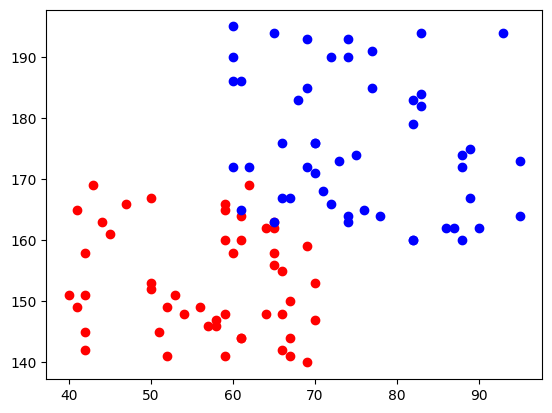

In [6]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
         [male[1] for male in data[1::2]], 'o', color='b')
plt.show()

# 2. 군집화 로직

In [9]:
# 초기 랜덤 지점 2개
random_points = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_points[0], random_points[1] 

([41, 144], [77, 185])

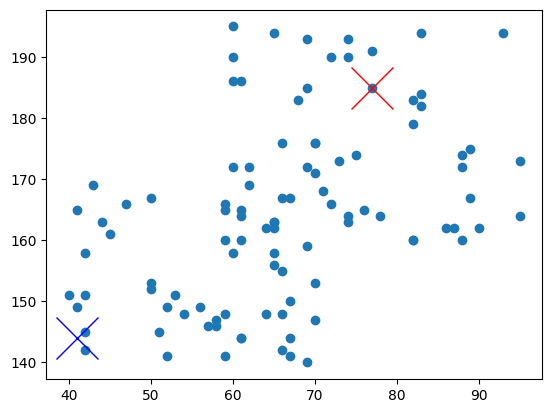

In [10]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b') # 기준점 0
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r') # 기준점 1

In [11]:
# 두점 거리를 return하는 함수 점은 [50, 160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [16]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_points[0], d) < dist(random_points[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(49, 51)

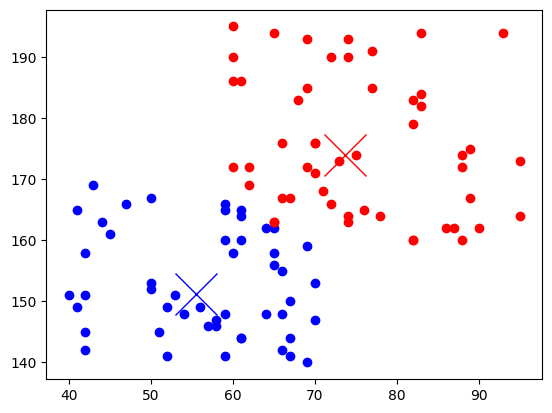

In [17]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()

In [18]:
# group0과 group1 중심점으로 기준점을 이동
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_points[1] = [group1_meanX, group1_meanY]
random_points

[[56.53061224489796, 152.9387755102041],
 [75.2156862745098, 175.47058823529412]]

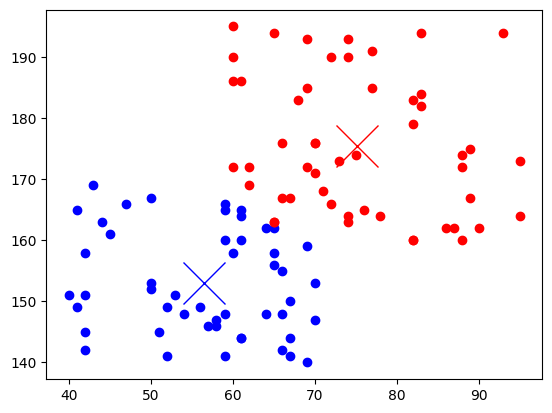

In [19]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()

# 3. 군집화 전체 코드(for문 이용)
- 랜덤포인트 2개 지정 - 출력 및 시각화
- for문 
    * 랜덤 포인트 2지점 기준으로 group0과 group1을 나눔
    * group0의 중간점과 group1의 중간지점을 랜덤포인트로 업데이트
    * 랜덤 포인트 출력 및 시각화

초기 지점 : [[50, 145], [75, 181]]
1 번째 points : [[55.72727272727273, 151.8181818181818], [74.17857142857143, 174.33928571428572]]
2 번째 points : [[56.86274509803921, 153.33333333333334], [75.63265306122449, 175.9795918367347]]
3 번째 points : [[56.86274509803921, 153.33333333333334], [75.63265306122449, 175.9795918367347]]
4 번째 points : [[56.86274509803921, 153.33333333333334], [75.63265306122449, 175.9795918367347]]
5 번째 points : [[56.86274509803921, 153.33333333333334], [75.63265306122449, 175.9795918367347]]
6 번째 points : [[56.86274509803921, 153.33333333333334], [75.63265306122449, 175.9795918367347]]
7 번째 points : [[56.86274509803921, 153.33333333333334], [75.63265306122449, 175.9795918367347]]
8 번째 points : [[56.86274509803921, 153.33333333333334], [75.63265306122449, 175.9795918367347]]
9 번째 points : [[56.86274509803921, 153.33333333333334], [75.63265306122449, 175.9795918367347]]
10 번째 points : [[56.86274509803921, 153.33333333333334], [75.63265306122449, 175.9795918367347]]


(140.0, 195.0)

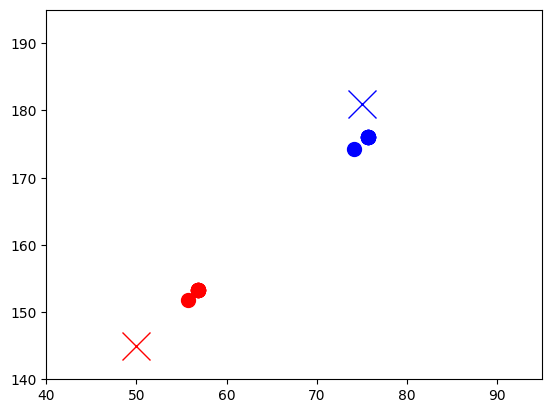

In [37]:
points = [
    [random.randint(40,95), random.randint(140,195)],
    [random.randint(40,95), random.randint(140,195)],
]
print('초기 지점 :', points)
plt.plot(points[0][0], points[0][1], 'x', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'x', color='b', markersize=20)
for i in range(1, 11): # 10번
    # points 두 지점을 기준으로 group0과 group1 나누기
    group0 = []
    group1 = []
    for info in data:
        if dist(points[0], info) < dist(points[1], info):
            group0.append(info)
        else:
            group1.append(info)
    # group0의 중간점, group1의 중간점으로 points업데이트
    meanX = np.mean([g[0] for g in group0])
    meanY = np.mean([g[1] for g in group0])
    points[0] = [meanX, meanY]
    
    meanX = np.mean([g[0] for g in group1])
    meanY = np.mean([g[1] for g in group1])
    points[1] = [meanX, meanY]
    # 업데이트된 points 출력 및 시각화
    print(i, '번째 points :', points)
    plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=10)
    plt.plot(points[1][0], points[1][1], 'o', color='b', markersize=10)
plt.xlim([40, 95])
plt.ylim([140, 195])

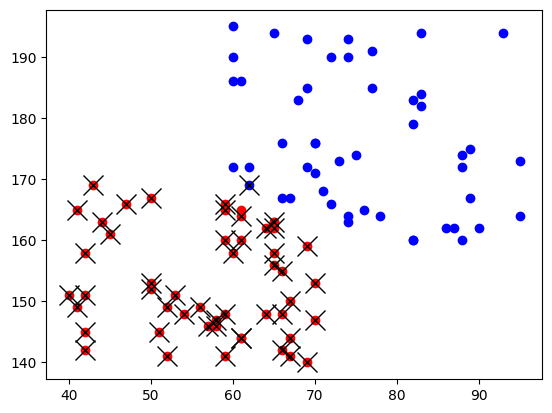

In [40]:
plt.plot([g[0] for g in group0],
         [g[1] for g in group0], 'o', color='r')
plt.plot([g[0] for g in group1],
         [g[1] for g in group1], 'o', color='b')
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'x', color='k', markersize=15)

# 4. api(sklearn)를 이용한 군집화
- sklearn : 머신러닝 패키지
    * 예측/군집 모델 : 회귀분석, 분류분석, 군집분석 - fit(학습), predict(예측, 분류)
    * 변환모델 : 전처리시 사용 ex.인코딩, 스케일조정... - fit(학습), transform(변환함수), fit_transform(학변)

In [43]:
# import os
# os.environ['OMP_NUM_THREADS'] = '1'
import warnings
warnings.filterwarnings(action='ignore') # 경고 무시

In [42]:
from sklearn.cluster import KMeans
data = np.array(data) # 원칙적으로 머신러닝 모델에는 넘파이 배열로 학습
model = KMeans(n_clusters=2, # 2개 그룹으로 군집화
              init='random', # 초기포인트를 random하게
              n_init=10,     # 10번 실행
              random_state=7) # 일관적인 모델을 생성하기 위한 seed 값
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [45]:
# 두 그룹의 기준점: [[56.86, 153.33], [75.63, 175.97]]
model.cluster_centers_

array([[ 75.63265306, 175.97959184],
       [ 56.8627451 , 153.33333333]])

In [44]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [46]:
group1 = data[model.labels_==1]
group0 = data[model.labels_==0]

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True,  True,  True, False,  True, False,  True, False,  True,
       False,  True,  True,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
       False, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False])

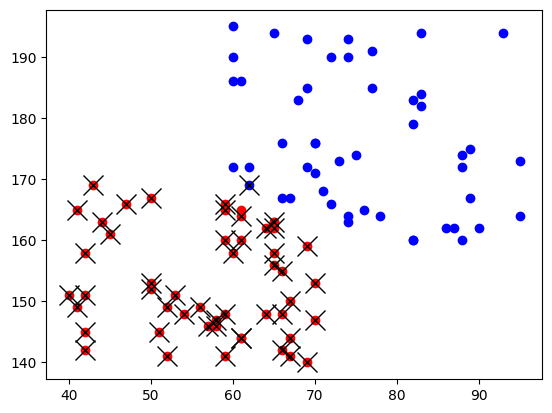

In [47]:
plt.plot([g[0] for g in group0],
         [g[1] for g in group0], 'o', color='r')
plt.plot([g[0] for g in group1],
         [g[1] for g in group1], 'o', color='b')
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'x', color='k', markersize=15)